In [3]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

Recall that the analytical posterior for our model is 

$$\theta | x=x_\text{obs} \sim N_{[-L, L]^d}(x_\text{obs}, \sigma^2 I_d)$$

Suppose we set $\sigma^2 = 1$ and we condition on observing $x_\text{obs}=0$, then our posterior is

$$\theta | x=0 \sim N_{[-L, L]^d}(0, I_d)$$

In this case, we aim to select the uniform bounds of the form $[-L, L]^d$ such that the posterior is approximately Gaussian (i.e. the truncation is neglible, because most of the mass of the Gaussian is inside $[-L, L]^d$). We can find an exact expression for $L$ since the elements of our posterior vectors are independent $N(0,1)$:

$$P\left( \bigcap_{i=1}^d \{\theta_i \in [-L,L]\} \right) = \prod_{i=1}^d P\left(\theta_i \in [-L,L]\right)$$

$$ = \left( \Phi(L) - \Phi(-L)\right)^d = \left( 2\Phi(L) - 1\right)^d$$

Thus, if we want a cube region that contains the vector with probability $p^* \in [0,1]$, we solve

$$\left( 2\Phi(L) - 1\right)^d \overset{\text{set}}{=} p^*$$

$$\implies L = \Phi^{-1}\left( \frac{(p^*)^\frac{1}{d} + 1}{2}\right)$$

We can also obtain a spherical CI for the vector, using the fact that $||\theta||^2 \sim \chi^2_d$:

$$P\left(||\theta|| \le R \right) = P\left(||\theta||^2 \le R^2 \right)$$

$$=F_{\chi^2_d}(R^2)$$

Thus, if we want a spherical region that contains the vector with probability $p^* \in [0,1]$, we solve

$$F_{\chi^2_d}(R^2) = p^*$$

$$\implies R = \sqrt{F_{\chi^2_d}^{-1}(p^*)}$$

Note that, for fixed $p^*$, the spherical CI clearly "spills outside" of the box CI. However, we choose to select $L$ to equal the radius of the spherical CI:

$$L = R = \sqrt{F_{\chi^2_d}^{-1}(p^*)}$$

which ensures that the $p^*$ probability region containing the vector is a sphere inscribed within the prior bounds. This allows us to examine what happens as we increase the dimension $d$, since the volume ratio of the $p^*$ probability sphere of the posterior divided by the volume of the prior bounds :

$$\frac{\text{vol}\left( \{\theta : ||\theta|| \le L\} \right)}{\text{vol}([-L,L]^d)} = \frac{\pi^{d/2}L^d}{(2L)^d \Gamma(1 + d/2)} = \left(\frac{\sqrt{\pi}}{2}\right)^d\frac{1}{\Gamma(1 + d/2)}$$

goes to zero as $d \to \infty$.

Intuitively, $p^*$ (usually 0.99) of the posterior mass is contained within the sphere with radius $L$, and this sphere is inscribed inside the prior region $[-L,L]^d$, where the ratio of the volume of the $p^*$ region to the volume of the prior region goes to zero as $d \to \infty$. Thus, we expect the inference algorithms to struggle as $d$ gets larger, since the prior mass region becomes tiny compared to the prior region.

In [4]:
def get_spherical_confidence_region(d, p=0.99):
    # Return the R such that a MVN(0,I_d) vector is contained in the sphere with radius R w/p p
    R_squared = scipy.stats.chi2.ppf(p, d)
    return np.sqrt(R_squared)


def get_cube_confidence_region(d, p=0.99):
    # Return the L such that a MVN(0, I_d) vector is contained in [-L,L]^d w/p p
    L = scipy.stats.norm.ppf((p**(1/d) + 1)/2)
    return L


def vol_ratio(L, d):
    # Return volume ratio of a sphere of radius L inscribed inside [-L,L]^d
    vol_sphere = np.pi**(d/2) * L ** d / scipy.special.gamma(1 + d/2)
    vol_cube = (2*L)**d
    return vol_sphere/ vol_cube


def log10_vol_ratio(L, d):
    # Return log base 10 of volume ratio of a sphere of radius L inscribed inside [-L,L]^d
    log_vol_sphere = (d/2) * np.log10(np.pi) + d * np.log10(L) - np.log10(scipy.special.gamma(1 + d/2))
    log_vol_cube = d * np.log10(2*L)
    return log_vol_sphere - log_vol_cube

In [6]:
d = 25
Ld = get_spherical_confidence_region(d=d, p=0.99)
print(f"Ld = {Ld}")
vr = vol_ratio(L=Ld, d=d)
print(f"Volume ratio is {vr}")

Ld = 6.656884023041046
Volume ratio is 2.854235198566831e-11


Text(0.5, 1.0, 'Posterior volume ratio against dimensionality $d$')

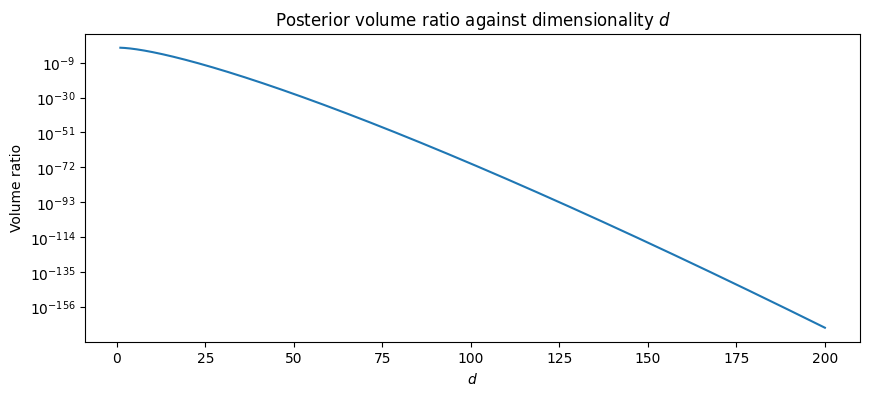

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
d_range = np.linspace(1, 200, 1000)
ax.plot(d_range, vol_ratio(L=1, d=d_range))
ax.set_yscale("log")
ax.set_xlabel(r"$d$")
ax.set_ylabel("Volume ratio")
ax.set_title(r"Posterior volume ratio against dimensionality $d$")


Text(0.5, 1.0, 'Prior width $L_d$ against dimensionality $d$')

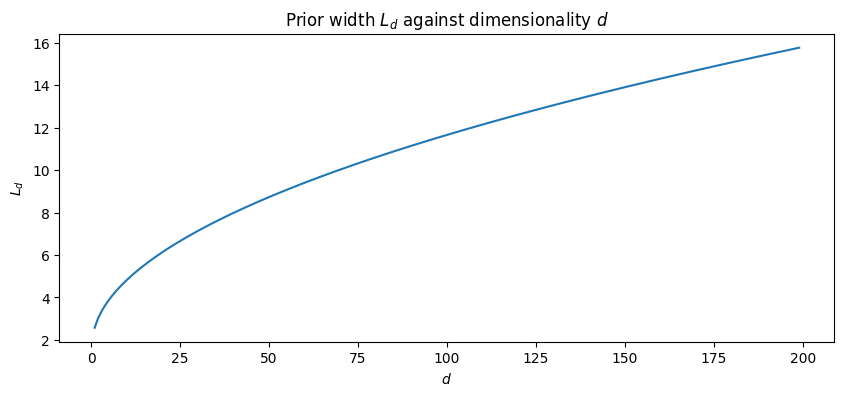

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
d_range = np.array(range(1, 200))
ax.plot(d_range, get_spherical_confidence_region(d_range, p=0.99))
ax.set_xlabel(r"$d$")
ax.set_ylabel(r"$L_d$")
ax.set_title(r"Prior width $L_d$ against dimensionality $d$")


In [17]:
def tighter_bound(d):
    Ld = np.sqrt(scipy.stats.chi2.ppf(0.99, df=d))
    return 2 * (1 - (2 * scipy.stats.norm.cdf(Ld) - 1)**d)

def bound(d):
    return 4 * d * np.exp(-0.5 * d + np.sqrt(d * np.log(1 / 0.99)))

Text(0.5, 1.0, 'A bound on the total variation distance between a $\\chi^2_d$ distribution and the \n squared norm distribution under the exact posterior')

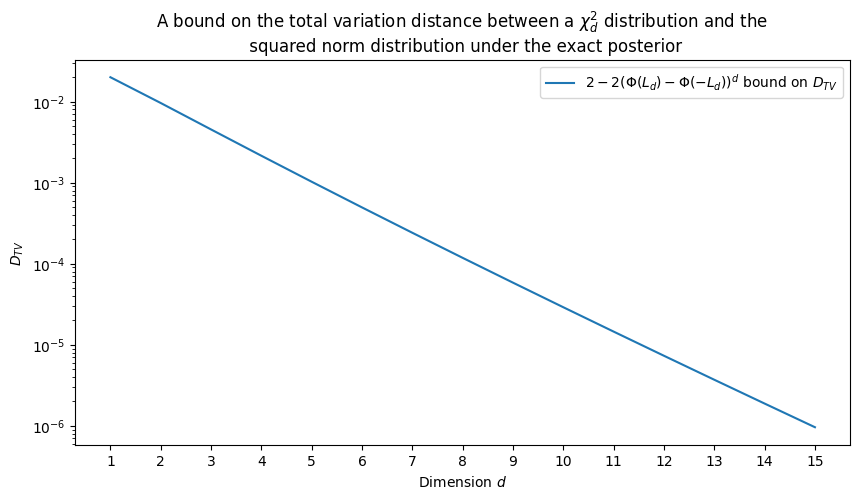

In [18]:
fig, ax = plt.subplots(figsize=(10,5))
ds = np.array(range(1, 16))
ax.plot(ds, tighter_bound(ds), label=r"$2 - 2(\Phi(L_d) - \Phi(-L_d))^d$ bound on $D_{TV}$")
#ax.plot(ds[8:], bound(ds[8:]), label=r"$D_{TV}$ bound")
ax.set_xticks(ds)
ax.set_xlabel(r"Dimension $d$")
ax.set_ylabel(r"$D_{TV}$")
ax.set_yscale("log")
ax.legend()
ax.set_title(r"A bound on the total variation distance between a $\chi^2_d$ distribution" +" and the \n squared norm distribution under the exact posterior")